In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.60,
    random_state=42
)
df_kmeans = pd.DataFrame(
    X,
    columns=['Feature_1', 'Feature_2']
)
print("Original K-Means Dataset Head:")
print(df_kmeans.head())

Original K-Means Dataset Head:
   Feature_1  Feature_2
0  -7.155244  -7.390016
1  -7.395875  -7.110843
2  -2.015671   8.281780
3   4.509270   2.632436
4  -8.102502  -7.484961


In [3]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
print("WCSS values:")
print(wcss)

WCSS values:
[19884.398329041524, 5335.122314158596, 204.06943840478868, 179.33291317971714, 153.7469532815127, 131.39885751526347, 110.97789763816479, 97.23083183136868, 84.36747906985966, 78.34021937033557]


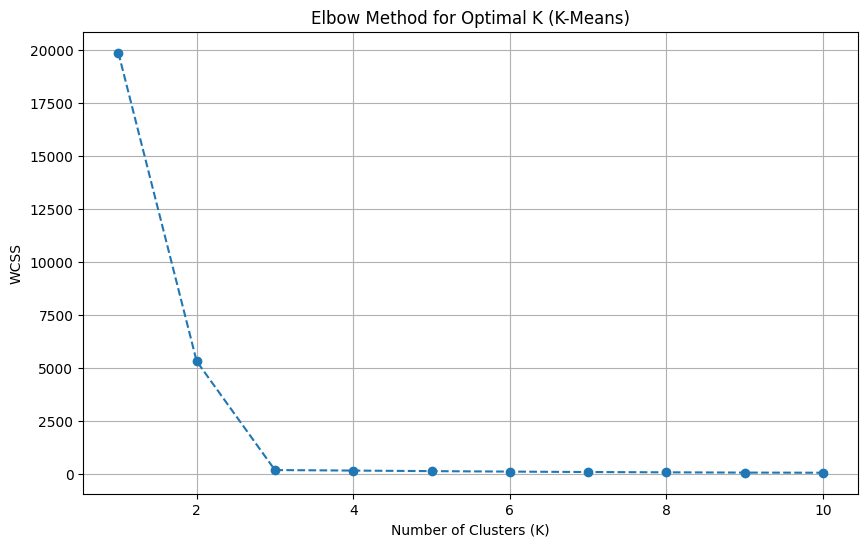

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, 11),
    wcss,
    marker='o',
    linestyle='--'
)
plt.title('Elbow Method for Optimal K (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [5]:
optimal_k = 3

In [6]:
optimal_k = 3
kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)
clusters = kmeans.fit_predict(X)
df_kmeans['Cluster'] = clusters
print("K-Means Clustered Dataset:")
print(df_kmeans.head())

K-Means Clustered Dataset:
   Feature_1  Feature_2  Cluster
0  -7.155244  -7.390016        1
1  -7.395875  -7.110843        1
2  -2.015671   8.281780        0
3   4.509270   2.632436        2
4  -8.102502  -7.484961        1


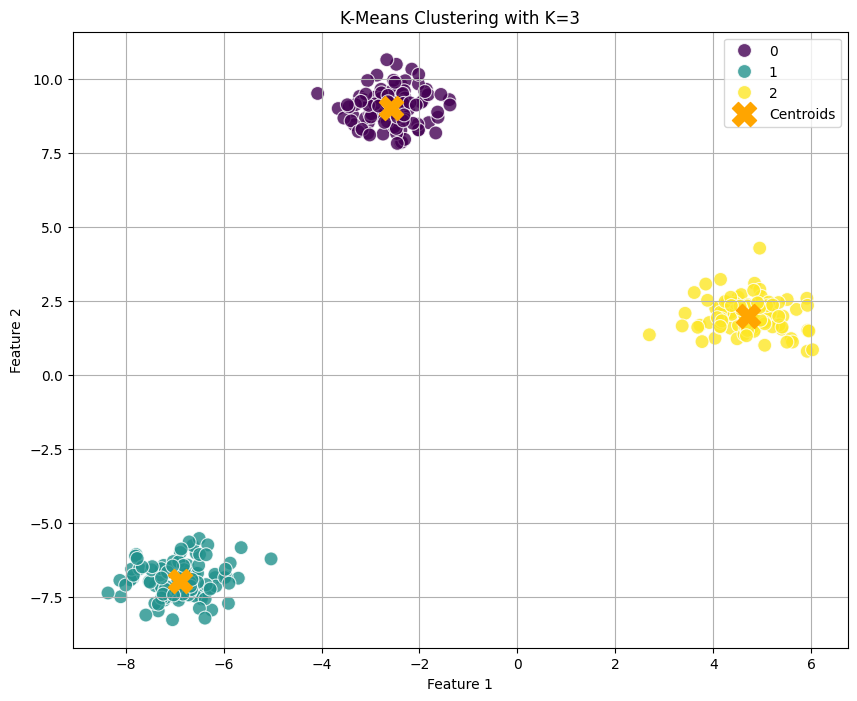

In [8]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Feature_1',
    y='Feature_2',
    hue='Cluster',
    data=df_kmeans,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='orange',
    marker='X',
    label='Centroids'
)
plt.title(f'K-Means Clustering with K={optimal_k}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
silhouette_avg = silhouette_score(X, clusters)
print(
    f"Silhouette Score for K-Means (K={optimal_k}): "
    f"{silhouette_avg:.3f}"
)

Silhouette Score for K-Means (K=3): 0.908


In [10]:
X_pca, y_pca = make_blobs(
    n_samples=500,
    n_features=4,
    centers=4,
    cluster_std=1.0,
    random_state=25
)
df_pca_original = pd.DataFrame(
    X_pca,
    columns=[f'Feature_{i+1}' for i in range(X_pca.shape[1])]
)
df_pca_original['True_Cluster'] = y_pca
print("Original PCA Dataset Head:")
print(df_pca_original.head())
print("\nOriginal PCA Dataset Shape:")
print(df_pca_original.shape)

Original PCA Dataset Head:
   Feature_1  Feature_2  Feature_3  Feature_4  True_Cluster
0  -0.638667   1.110057  -6.400722  -0.204990             3
1  -2.951556  -7.657445   3.844794   0.903589             1
2  -0.253177   2.125103  -7.869801   0.559678             3
3  -2.151209   3.401400  -5.734930   0.965230             3
4  -2.347519  -7.230467   3.478891  -0.443440             1

Original PCA Dataset Shape:
(500, 5)


In [11]:
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)
print("Standardized PCA Dataset:")
print(X_pca_scaled[:5])

Standardized PCA Dataset:
[[-0.55928622  0.72007991 -1.02250751  0.99445574]
 [-1.18201688 -1.52375963  1.51618325  1.30371915]
 [-0.45549537  0.97985745 -1.38652397  1.20777714]
 [-0.96652842  1.30649614 -0.85753395  1.32091525]
 [-1.01938377 -1.41448436  1.42551792  0.9279346 ]]


In [12]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_pca_scaled)
df_principal_components = pd.DataFrame(
    principal_components,
    columns=[
        'Principal_Component_1',
        'Principal_Component_2'
    ]
)
df_principal_components['True_Cluster'] = y_pca
print("Principal Components Head:")
print(df_principal_components.head())

Principal Components Head:
   Principal_Component_1  Principal_Component_2  True_Cluster
0               0.455305               1.623917             3
1              -2.705622               0.375012             1
2               0.810234               1.966926             3
3               0.427139               2.149626             3
4              -2.407508               0.099250             1


NameError: name 'explained_variance' is not defined

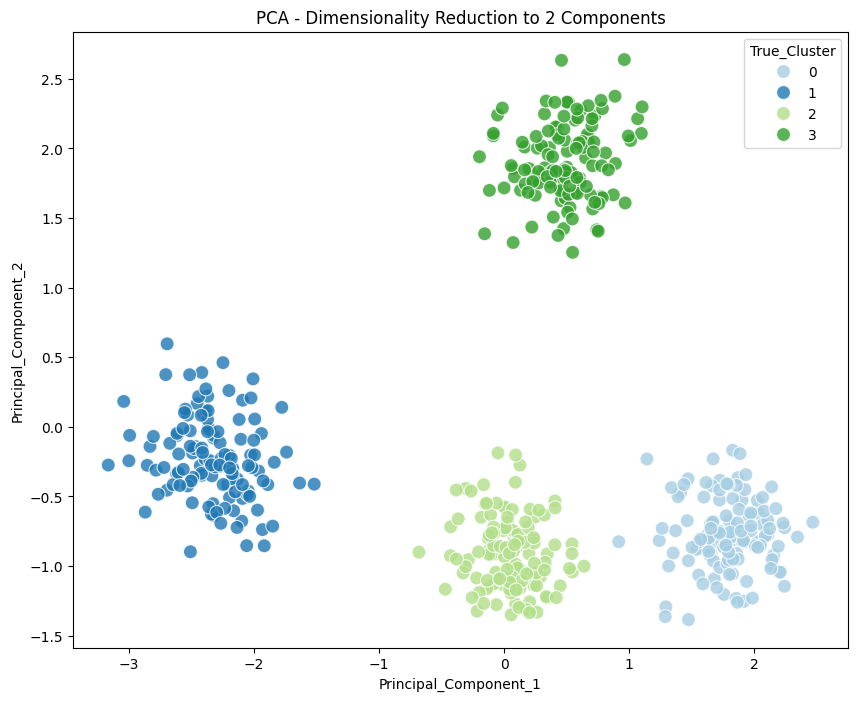

In [13]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal_Component_1',
    y='Principal_Component_2',
    hue='True_Cluster',
    data=df_principal_components,
    palette='Paired',
    s=100,
    alpha=0.8
)
plt.title('PCA - Dimensionality Reduction to 2 Components')
plt.xlabel(
    f'PC1 ({explained_variance[0] * 100:.2f}%)'
)
plt.ylabel(
    f'PC2 ({explained_variance[1] * 100:.2f}%)'
)
plt.grid(True)
plt.show()

In [14]:
kmeans_pca = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters_pca = kmeans_pca.fit_predict(principal_components)

df_principal_components['KMeans_Cluster_on_PCA'] = clusters_pca

print("K-Means Clusters on PCA Data:")
print(df_principal_components.head())

K-Means Clusters on PCA Data:
   Principal_Component_1  Principal_Component_2  True_Cluster  \
0               0.455305               1.623917             3   
1              -2.705622               0.375012             1   
2               0.810234               1.966926             3   
3               0.427139               2.149626             3   
4              -2.407508               0.099250             1   

   KMeans_Cluster_on_PCA  
0                      0  
1                      2  
2                      0  
3                      0  
4                      2  


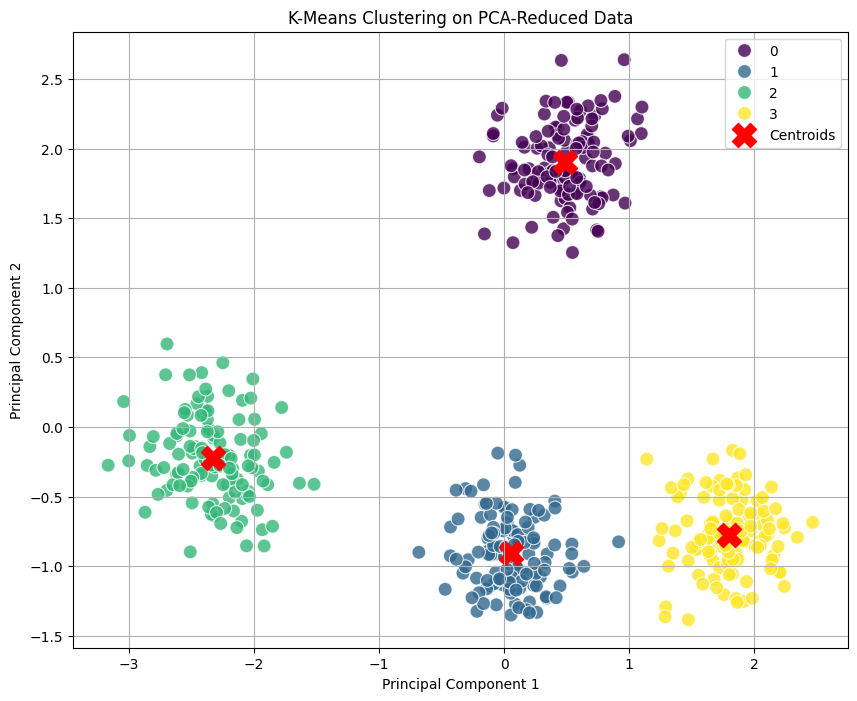

In [15]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='Principal_Component_1',
    y='Principal_Component_2',
    hue='KMeans_Cluster_on_PCA',
    data=df_principal_components,
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.scatter(
    kmeans_pca.cluster_centers_[:, 0],
    kmeans_pca.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clustering on PCA-Reduced Data')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend()
plt.grid(True)

plt.show()

In [16]:
silhouette_avg_pca = silhouette_score(
    principal_components,
    clusters_pca
)

print(
    f"Silhouette Score for K-Means on "
    f"PCA-Reduced Data (K=4): "
    f"{silhouette_avg_pca:.3f}"
)

Silhouette Score for K-Means on PCA-Reduced Data (K=4): 0.776
